<a href="https://colab.research.google.com/github/Tarinis-Git/Tarinis-Git/blob/main/zomatoReview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **- By TARINI**

KNOW YOUR DATA

In [ ]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans

In [ ]:
#LOAD DATA SET
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
meta_df = pd.read_csv('/content/Zomato Restaurant names and Metadata.csv')
rv_df = pd.read_csv('/content/Zomato Restaurant reviews.csv')

In [ ]:
#Data View for meta data
meta_df.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [ ]:
#Data View for review
rv_df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


In [ ]:
meta_df.tail()

,Name,Links,Cost,Collections,Cuisines,Timings
100,IndiBlaze,https://www.zomato.com/hyderabad/indiblaze-gac...,600,NaN,"Fast Food, Salad",11 AM to 11 PM
101,Sweet Basket,https://www.zomato.com/hyderabad/sweet-basket-...,200,NaN,"Bakery, Mithai","10 AM to 10 PM (Mon-Thu), 8 AM to 10:30 PM (Fr..."
102,Angaara Counts 3,https://www.zomato.com/hyderabad/angaara-count...,500,NaN,"North Indian, Biryani, Chinese",12 Noon to 11 PM
103,Wich Please,https://www.zomato.com/hyderabad/wich-please-1...,250,NaN,Fast Food,8am to 12:30AM (Mon-Sun)
104,Republic Of Noodles - Lemon Tree Hotel,https://www.zomato.com/hyderabad/republic-of-n...,"1,700",Pan-Asian Delicacies,"Thai, Asian, Chinese, Malaysian","11:30 AM to 3 PM, 7 PM to 12 Midnight"


In [ ]:
rv_df.tail()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
9995,Chinese Pavilion,Abhishek Mahajan,Madhumathi Mahajan Well to start with nice cou...,3,"53 Reviews , 54 Followers",06-05-2016 00:08,0
9996,Chinese Pavilion,Sharad Agrawal,This place has never disappointed us.. The foo...,4.5,"2 Reviews , 53 Followers",06-04-2016 22:01,0
9997,Chinese Pavilion,Ramandeep,"Bad rating is mainly because of ""Chicken Bone ...",1.5,"65 Reviews , 423 Followers",06-03-2016 10:37,3
9998,Chinese Pavilion,Nayana Shanbhag,I personally love and prefer Chinese Food. Had...,4,"13 Reviews , 144 Followers",5/31/2016 17:22,0
9999,Chinese Pavilion,Bhargava Krishna,Checked in here to try some delicious chinese ...,3.5,"472 Reviews , 1302 Followers",5/31/2016 16:41,6


In [ ]:
# Dataset Rows & Columns Count
print("Resturant MetaData :",meta_df.shape)
print("Resturant review : ",rv_df.shape)

Resturant MetaData : (105, 6)
Resturant review :  (10000, 7)


In [ ]:
#Dataset Information for both meta and review data
meta_df.info()
print()
rv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


In [ ]:
# Checking for duplicate values in meta and review data
print('Duplicate values in meta dataset:',meta_df.duplicated().sum())
print()
print('Duplicate values in dataset:',rv_df.duplicated().sum())

Duplicate values in meta dataset: 0

Duplicate values in dataset: 36


In [ ]:
#missing and null values
print(meta_df.isnull().sum())
print()
print(rv_df.isnull().sum())

Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64

Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64


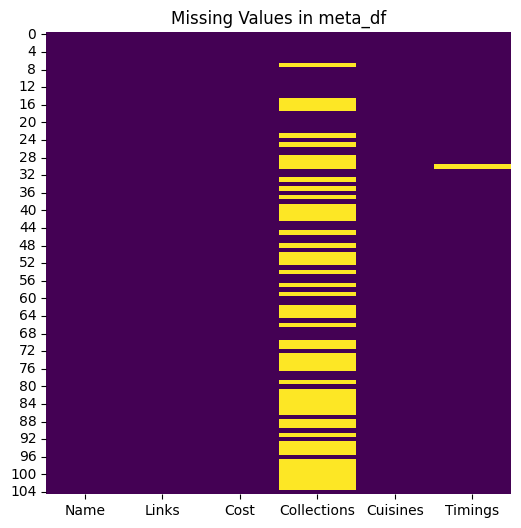

In [ ]:
# Visualizing the missing values

# Visualize missing values in the meta_df dataset
plt.figure(figsize=(6, 6))
sns.heatmap(meta_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in meta_df')
plt.show()


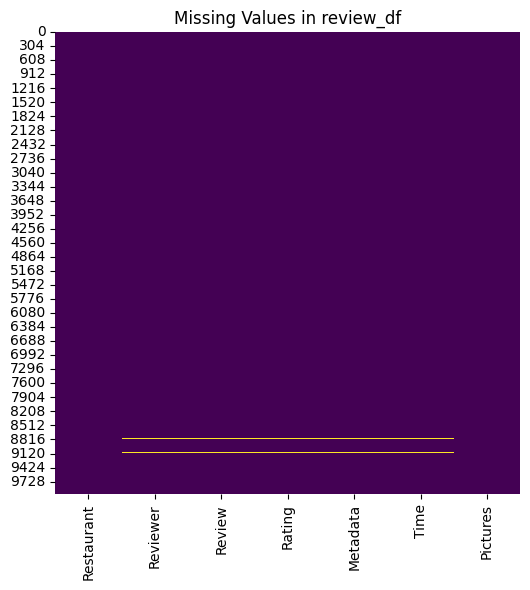

In [ ]:
# Visualize missing values in the review_df dataset
plt.figure(figsize=(6, 6))
sns.heatmap(rv_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in review_df')
plt.show()

UNDERSTANDING YOUR VARIABLES

In [ ]:
# Finding Dataset in meta column
meta_df.columns

Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object')

In [ ]:
# Finding Dataset in review column
rv_df.columns

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')

In [ ]:
# Data description in meta_df
meta_df.describe(include = 'all')

,Name,Links,Cost,Collections,Cuisines,Timings
count,105,105,105,51,105,104
unique,105,105,29,42,92,77
top,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,500,Food Hygiene Rated Restaurants in Hyderabad,"North Indian, Chinese",11 AM to 11 PM
freq,1,1,13,4,4,6


In [ ]:
# Data description in rv_df
rv_df.describe(include = 'all')

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
count,10000,9962,9955,9962,9962,9962,10000.000000
unique,100,7446,9364,10,2477,9782,NaN
top,Beyond Flavours,Parijat Ray,good,5,1 Review,7/29/2018 20:34,NaN
freq,100,13,237,3832,919,3,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.748600
std,NaN,NaN,NaN,NaN,NaN,NaN,2.570381
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


CHECKING UNIQUE VALUES

In [ ]:
# Checking for unique value
print(("meta_dataframe:\n"),meta_df.nunique())
print()
print("Review_dataframe:\n",rv_df.nunique())

meta_dataframe:
 Name           105
Links          105
Cost            29
Collections     42
Cuisines        92
Timings         77
dtype: int64

Review_dataframe:
 Restaurant     100
Reviewer      7446
Review        9364
Rating          10
Metadata      2477
Time          9782
Pictures        36
dtype: int64


DATA WRANGLING

In [ ]:
# Code to make dataset analysis ready.
meta_df['Cost'] = meta_df['Cost'].str.replace(',','').astype('int64')

In [ ]:
# Removing null values from review
rv_df = rv_df.dropna()

In [ ]:
# Removing null values from review
rv_df.drop(rv_df[(rv_df['Rating']=='Like')].index,inplace=True)
rv_df['Rating']= rv_df['Rating'].astype('float64')
rv_df.shape

(9954, 7)

In [ ]:
# Extracting details from metadata
rv_df['Reviewer_Total_Review']=rv_df['Metadata'].str.split(',').str[0]
rv_df['Reviewer_Followers']=rv_df['Metadata'].str.split(',').str[1]
rv_df['Reviewer_Total_Review']=pd.to_numeric(rv_df['Reviewer_Total_Review'].str.split(' ').str[0])
rv_df['Reviewer_Followers']=pd.to_numeric(rv_df['Reviewer_Followers'].str.split(' ').str[1])

In [ ]:
rv_df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Reviewer_Total_Review,Reviewer_Followers
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,"1 Review , 2 Followers",5/25/2019 15:54,0,1,2.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,"3 Reviews , 2 Followers",5/25/2019 14:20,0,3,2.0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,"2 Reviews , 3 Followers",5/24/2019 22:54,0,2,3.0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,"1 Review , 1 Follower",5/24/2019 22:11,0,1,1.0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,"3 Reviews , 2 Followers",5/24/2019 21:37,0,3,2.0


In [ ]:
rv_df['Time'] = pd.to_datetime(rv_df['Time'], format='mixed', dayfirst=True)
rv_df['Review_Year'] = rv_df['Time'].dt.year
rv_df['Review_Month'] = rv_df['Time'].dt.month
rv_df['Review_Hour'] = rv_df['Time'].dt.hour

VISUALISATION

/tmp/ipython-input-3814939929.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=costlier, x='Cost', y='Name', palette='Reds_r')


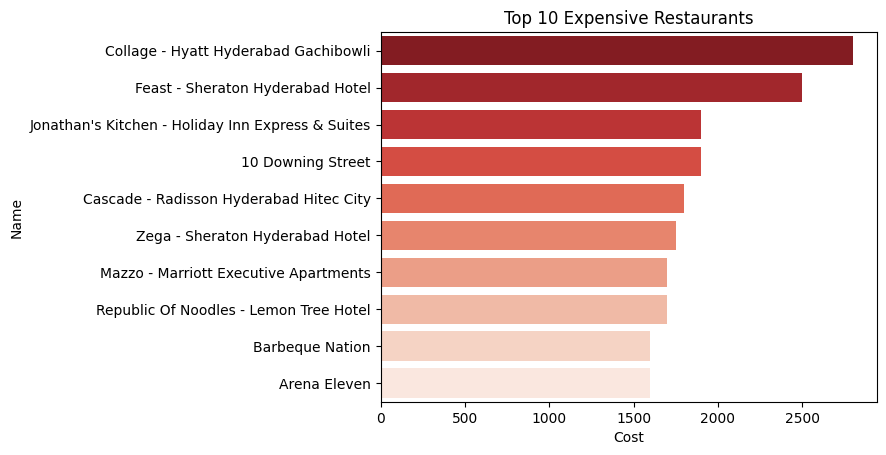

In [ ]:
#Top 10 Expensive Restaurants

# Sort and pick the top 10
costlier = meta_df.sort_values('Cost', ascending=False).head(10)

# Creating plot
sns.barplot(data=costlier, x='Cost', y='Name', palette='Reds_r')
plt.title('Top 10 Expensive Restaurants')
plt.show()

/tmp/ipython-input-2789879890.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=affordable, x='Cost', y='Name', palette='Greens_r')


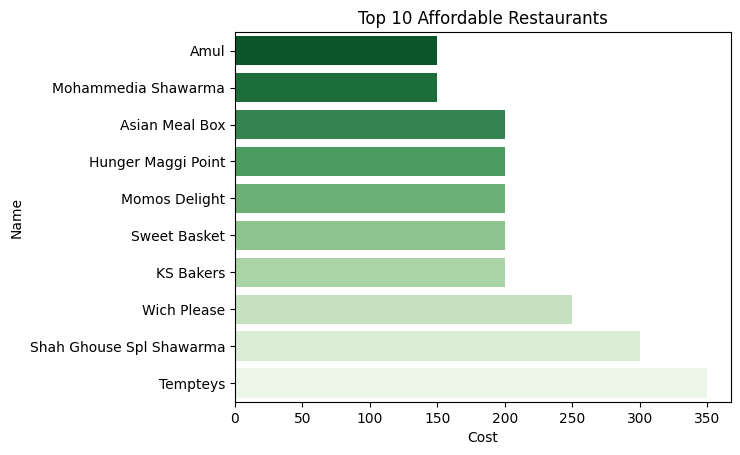

In [ ]:
#Top 10 Affordable Restaurants

# Sort and pick the bottom 10
affordable = meta_df.sort_values('Cost', ascending=True).head(10)

# Creating plot
sns.barplot(data=affordable, x='Cost', y='Name', palette='Greens_r')
plt.title('Top 10 Affordable Restaurants')
plt.show()

/tmp/ipython-input-526068938.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.index, y=top_cuisines.values, palette='inferno')


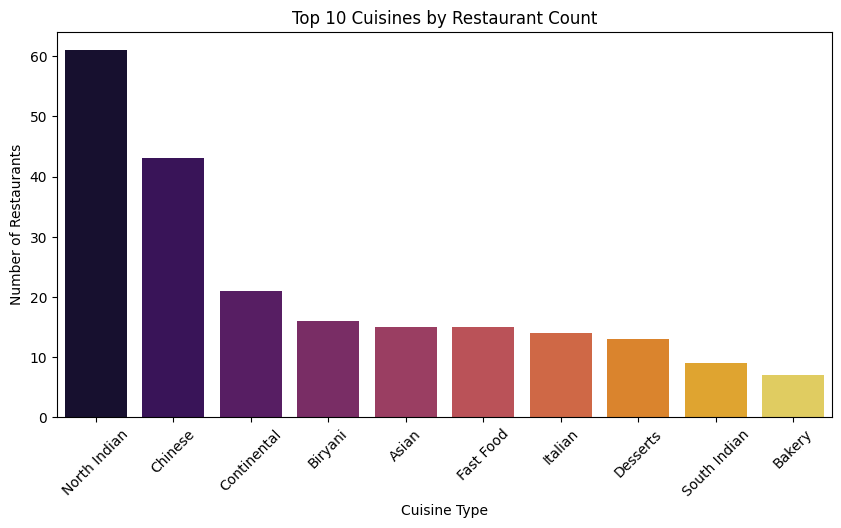

In [ ]:
# 1. Split the Cuisines into lists
temp_series = meta_df['Cuisines'].str.split(', ')

# 2.'explode' simply count how many times each cuisine appears
top_cuisines = temp_series.explode().value_counts().head(10)

# 3. Plotting
plt.figure(figsize=(10, 5))
sns.barplot(x=top_cuisines.index, y=top_cuisines.values, palette='inferno')

plt.title("Top 10 Cuisines by Restaurant Count")
plt.xlabel("Cuisine Type")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-1031871510.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Reviewer', y='Reviewer_Followers', palette='Blues_r')


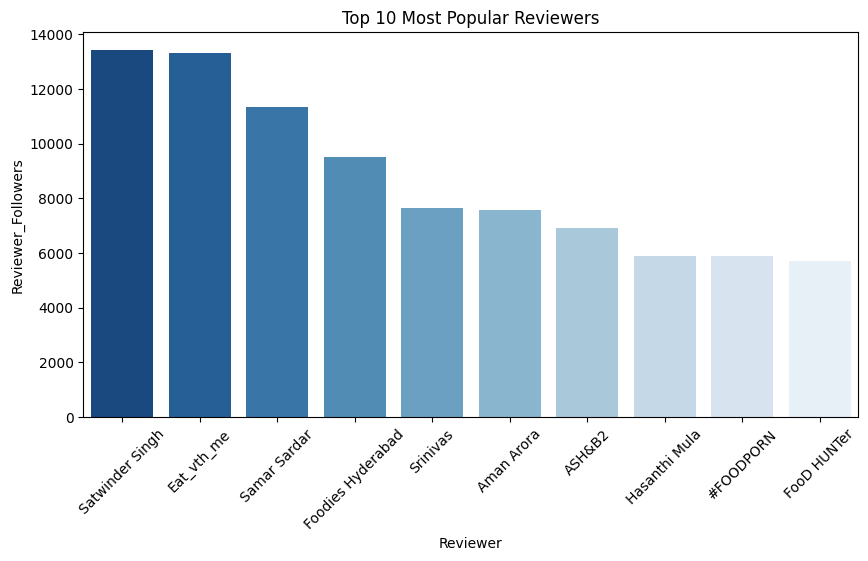

In [ ]:
# Top 10 Reviewers by Max Followers

influencers = rv_df.groupby('Reviewer')['Reviewer_Followers'].max().reset_index()
influencers = influencers.sort_values(by='Reviewer_Followers', ascending=False)
top_10 = influencers.head(10)

# Make the plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_10, x='Reviewer', y='Reviewer_Followers', palette='Blues_r')

# Step 5: Add titles and names on the bottom
plt.title("Top 10 Most Popular Reviewers")
plt.xticks(rotation=45) # Tilts the names so they don't overlap
plt.show()

Text(0.5, 1.0, 'Distribution of Restaurant Costs')

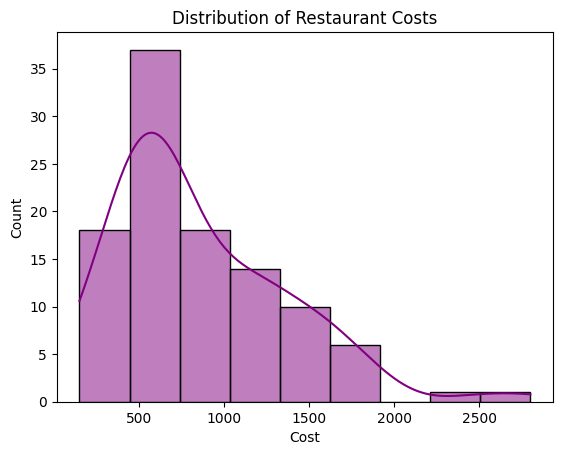

In [ ]:
sns.histplot(meta_df['Cost'], kde=True, color='purple')
plt.title("Distribution of Restaurant Costs")

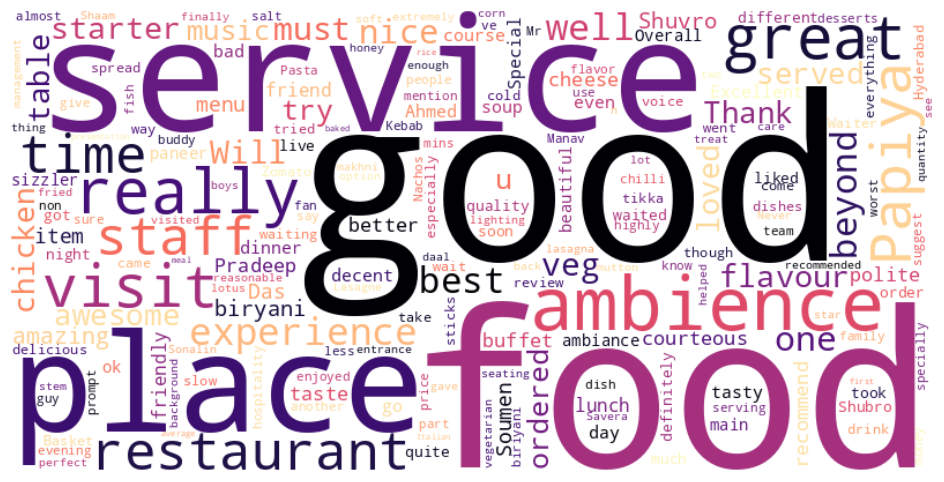

In [ ]:
#  IMPORT WordCloud
from wordcloud import WordCloud

# 1. Clean the data: Drop rows where Review is missing
clean_reviews = rv_df['Review'].dropna()

# 2. Combine the reviews into one giant string
# Let's take 100 reviews instead of 30 for a better looking cloud
text = " ".join(review for review in clean_reviews.head(100))

# 3. Create the WordCloud
word_cloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='magma', # Added nice color
    collocations=False
).generate(text)

# 4. Display the plot
plt.figure(figsize=(12, 6))
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis("off") # Hides the X and Y numbers
plt.show()

Merged successfully! New shape: (9954, 18)


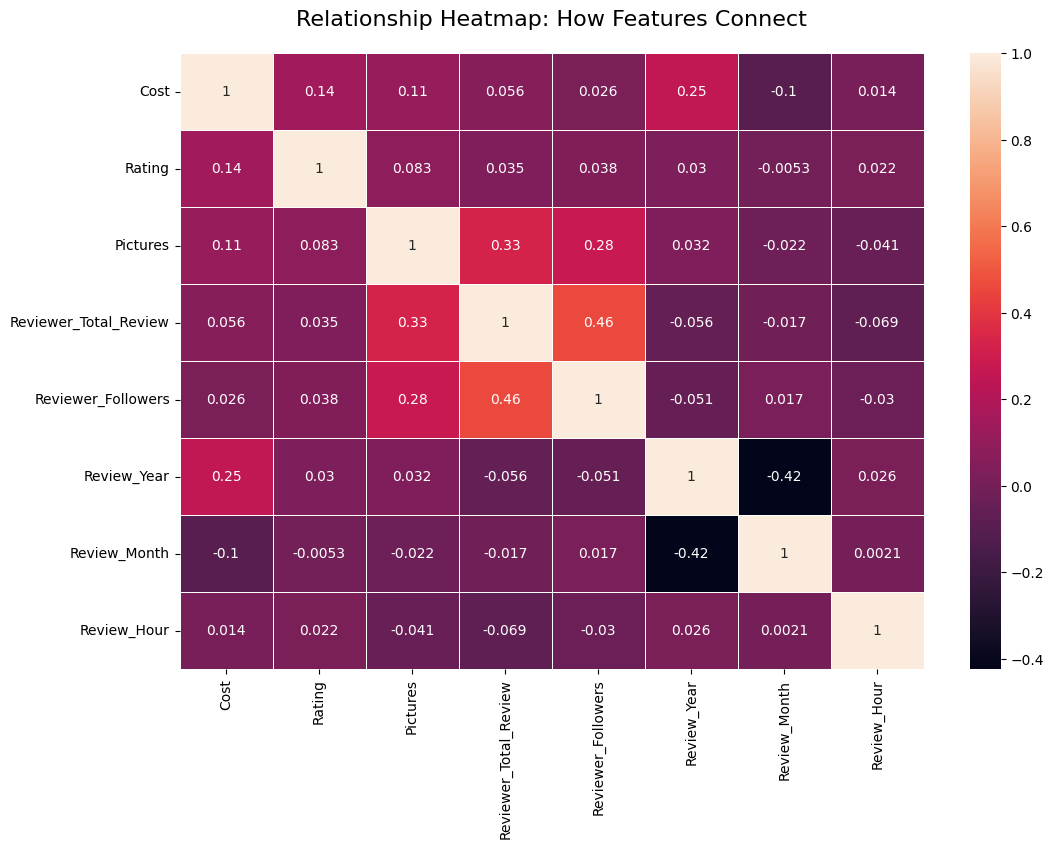

In [ ]:
# Relationship Heatmap

# 1. First, define the variable (Cost, Rating , pictures,Reviewer_Total_Review,Reviewer_Followers,Review_year,Review_month,Review_Hours)
merged = pd.merge(meta_df, rv_df, left_on='Name', right_on='Restaurant')

# Now check if it worked
print(f"Merged successfully! New shape: {merged.shape}")
numeric_data = merged.select_dtypes(include=['number'])
correlation_matrix = numeric_data.corr()

# 2.plotting
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='rocket', linewidths=0.5)

# 3. Add your title
plt.title("Relationship Heatmap: How Features Connect", fontsize=16, pad=20)

plt.show()

In [ ]:
from scipy import stats

# 1. Create two groups: High Cost vs Low Cost
# Let's say 'expensive' is above the median price
median_cost = merged['Cost'].median()
expensive = merged[merged['Cost'] >= median_cost]['Rating']
cheap = merged[merged['Cost'] < median_cost]['Rating']

# 2. Perform a T-Test (Comparing the means of two groups)
t_stat, p_val = stats.ttest_ind(expensive.dropna(), cheap.dropna())

print(f"P-Value: {p_val}")

# 3. The "Beginner" Conclusion for the report:
if p_val < 0.05:
    print("Insight: Yes! There is a significant difference in ratings based on cost.")
else:
    print("Insight: No. Cost doesn't strictly determine the rating.")


P-Value: 1.653723265971571e-34
Insight: Yes! There is a significant difference in ratings based on cost.


In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Pick the numbers you want to use for clustering
# We usually use Cost, Rating, and maybe Reviewer_Followers
features = merged[['Cost', 'Rating']].dropna()

# 2. Scaling is MANDATORY for K-Means
# If you don't scale, 'Cost' (800) will overwhelm 'Rating' (4.5)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print("Data is now scaled and ready for clustering!")

Data is now scaled and ready for clustering!


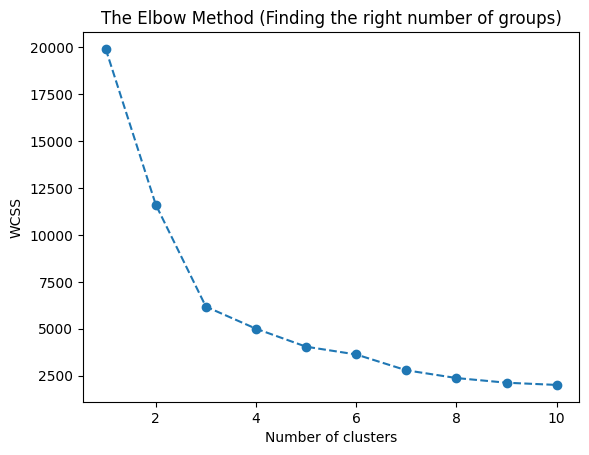

In [ ]:
from sklearn.cluster import KMeans

wcss = [] # This stores the "error" for each cluster count
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method (Finding the right number of groups)')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

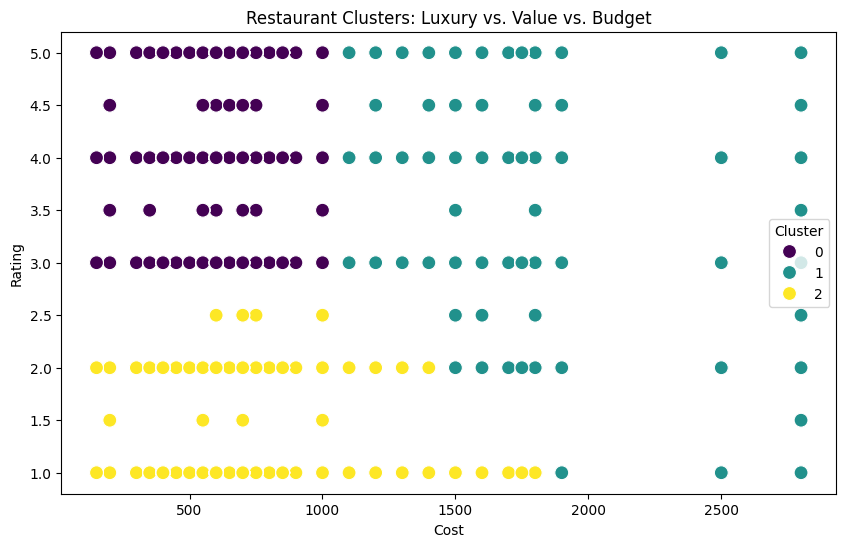

In [ ]:
# 1. Run KMeans with the best number (e.g., 3)
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
merged['Cluster'] = kmeans.fit_predict(scaled_features)

# 2. Plot the result
plt.figure(figsize=(10,6))
sns.scatterplot(data=merged, x='Cost', y='Rating', hue='Cluster', palette='viridis', s=100)
plt.title("Restaurant Clusters: Luxury vs. Value vs. Budget")
plt.show()

In [ ]:
# final clustering code
cluster_summary = merged.groupby('Cluster')[['Cost', 'Rating']].mean()
print("Cluster Characteristics:")
print(cluster_summary)

Cluster Characteristics:
                Cost    Rating
Cluster                       
0         601.282834  4.310324
1        1522.146539  4.308174
2         683.777396  1.275462
